|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>Tokenizations and embeddings<h1>|
|<h2>Section:</h2>|<h1>Words to tokens to numbers<h1>|
|<h2>Lecture:</h2>|<h1><b>Preparing text for tokenization<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# typical libraries...
import numpy as np

# for importing and working with texts
import requests
import re
import string

import matplotlib.pyplot as plt

# Get text from the web

In [ ]:
# get raw text from internet
book = requests.get('https://www.gutenberg.org/files/35/35-0.txt')

# extract just the text and have a look at it
text = book.text
# print(type(text))
# print(len(text))

# text[:2000]
# character strings to replace with space
strings2replace = [
                 '\r\n\r\nâ\x80\x9c', # new paragraph
                 'â\x80\x9c',         # open quote
                 'â\x80\x9d',         # close quote
                 '\r\n',              # new line
                 'â\x80\x94',         # hyphen
                 'â\x80\x99',         # single apostrophe
                 'â\x80\x98',         # single quote
                 '_',                 # underscore, used for stressing
                 ]

# e.g., 'â\x80\x9d'.encode('latin1').decode('utf8')

# use regular expression (re) to replace those strings with space
for str2match in strings2replace:
  regexp = re.compile(r'%s'%str2match)
  text = regexp.sub(' ',text)

# remove non-ASCII characters
text = re.sub(r'[^\x00-\x7F]+', ' ', text)

# remove numbers
text = re.sub(r'\d+','',text)

def get_words(text):
  # and make everything lower-case
  text = text.lower()

  # split by punctuation
  puncts4re = fr'[{string.punctuation}\s]+'
  words = re.split(puncts4re,text)
  words = [item.strip() for item in words if item.strip()]
  words = [item for item in words if len(item)>1]

  return words

words = get_words(text)
words = ['<|unc|>'] + words

# create the vocab! (set of unique words)
vocab = sorted(set(words))

# convenience variables for later
nWords = len(words)
nLex = len(vocab)

print(f'{nWords} words')
print(f' {nLex} unique tokens')

word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for i,w in enumerate(vocab)}

# print out a few
for i in list(word2idx.items())[0:10000:87]:
  print(i)


<|unc|>
30699 words
 4590 unique tokens
('<|unc|>', 0)
('ahead', 87)
('apertures', 174)
('attacked', 261)
('begun', 348)
('bosses', 435)
('camphor', 522)
('cheerful', 609)
('coal', 696)
('contented', 783)
('cube', 870)
('degree', 957)
('dimly', 1044)
('drag', 1131)
('edifice', 1218)
('everything', 1305)
('facet', 1392)
('filthily', 1479)
('football', 1566)
('furnish', 1653)
('going', 1740)
('hall', 1827)
('hiding', 1914)
('ideals', 2001)
('inevitably', 2088)
('inversion', 2175)
('lameness', 2262)
('likeness', 2349)
('man', 2436)
('mineralogy', 2523)
('myself', 2610)
('noun', 2697)
('out', 2784)
('paused', 2871)
('plates', 2958)
('previous', 3045)
('question', 3132)
('reflected', 3219)
('retreating', 3306)
('same', 3393)
('sense', 3480)
('shreds', 3567)
('slips', 3654)
('speaking', 3741)
('stepping', 3828)
('sucked', 3915)
('tangled', 4002)
('threw', 4089)
('treasures', 4176)
('unfinished', 4263)
('versatility', 4350)
('wear', 4437)
('wondered', 4524)


# Create token dictionaries and encoder/decoder functions

In [ ]:
# encoder function (using for-loop instead of list-comp)
def encoder(words,encode_dict):

  # initialize a vector of numerical indices
  idxs = np.zeros(len(words),dtype=int)

  # loop through the words and find their token in the vocab
  for i,w in enumerate(words):
    try:
      idxs[i] = encode_dict[w]
    except:
      idxs[i] = 0 

  # return the indices!
  return idxs


# also need a decoder function
def decoder(idxs,decode_dict):
  return ' '.join([decode_dict[i] for i in idxs])


# test the encoder
print(encoder(['the','time','machine'],word2idx))

# test the decoder
print(decoder([1,3,10],idx2word))


[4043 4110 2417]
abandon able absence


In [4]:
# # test encode-then-decode

# # random start location
# startidx = np.random.choice(nWords)

# # sequential word indices
# idxs = np.arange(startidx,startidx+10)

# print('Word indices:')
# print(idxs), print('')

# print('The words:')
# wordseq = [ words[i] for i in idxs ]
# print(wordseq), print('')

# print('Token indices:')
# tokenseq = encoder(wordseq,word2idx)
# print(tokenseq), print('')

# # decode
# print('Decoded text from indices:')
# decoder(tokenseq,idx2word)

In [5]:
selection = np.random.randint(nLex, size=10)

print(decoder(selection, idx2word))


substances admitted remember moment nitrates loomed choking insects deceived others


In [6]:
starting_index = np.random.randint(nLex - 50)

brownian_indices = []
max_length = 20

index = starting_index

for i in range(max_length):
    noise_value = np.random.choice([-1, 1])
    index = index + noise_value
    brownian_indices.append(index)

print(decoder(brownian_indices, idx2word))



allen all allen all allen alliance allen all allen alliance almost aloft almost aloft almost aloft almost alliance allen alliance


[0.000e+00 0.000e+00 5.323e+03 7.406e+03 5.879e+03 3.647e+03 2.568e+03
 2.223e+03 1.455e+03 9.950e+02 6.580e+02 2.560e+02 1.950e+02 6.200e+01
 2.600e+01 4.000e+00 2.000e+00]


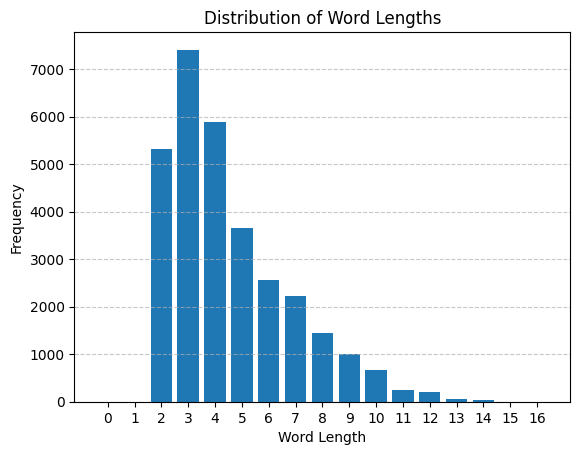

In [7]:
lword_characters = 0
lword = ""

for word in words:
    if len(word) > lword_characters:
        lword_characters = len(word)
        lword = word

word_length_distribution = np.zeros(lword_characters + 1)

for word in words:
    word_length_distribution[len(word)] += 1

print(word_length_distribution)

# plt.plot(word_length_distribution)

# Plotting the bar chart
plt.bar(np.arange(len(word_length_distribution)), word_length_distribution)

# Adding labels and title for clarity
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.title('Distribution of Word Lengths')

# Set x-axis tick locations to integers
xticks = np.arange(0, len(word_length_distribution), 1)  # integer increments
plt.xticks(xticks)

# Optionally, you can add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


In [9]:
sentence = "The space aliens came to earth to steal watermelons and staplers"

sentence = get_words(sentence)

encoder(sentence, word2idx)




ValueError: invalid literal for int() with base 10: '<|unc|>'